# Churn Dataset

- **Problem Type**: Classification
- **Evaluation Metric**: Recall
- **Models to test**:
  - Machine Learning
    - Logistic Regression (Base Model - If other models can't beat this then it's useless to use anything else because of higher inference cost)
    - Decision Tree Classifier
    - Random Forest Classifier
    - Support Vector Classifier
    - KNearestNeighbour Classifier
  - Boosting
    - XGBoost Classifier
    - LightGBM Classifier
  - Deep Learning
    - Artificial Neural Network

## Loading Libraries

In [1]:
import os

os.environ['KERAS_BACKEND'] = 'torch'

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.feature_selection import chi2

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.utils import class_weight

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings('ignore')

## Loading Dataset

In [ ]:
df_og = pd.read_csv("../data/churn.csv")
df_og.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## EDA

### Basic Info on Dataset

#### Check for the shape of our dataframe

In [3]:
df_og.shape

(7043, 21)

Our dataset contains 21 features and each having 7043 enteries i.e. we have 147903 data points

#### Check each column's data type

In [4]:
df_og.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

We have
- 3 numerical columns
- 18 categorical columns

Our target variable is Churn and is categorical column

#### Check for Null Values

In [5]:
df_og.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Stastical Inference

In [6]:
df_og.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


#### Conclusion

- 75 Quantile of 0 in Senior Citizen means that this dataset contains data for mostly young customers
- 50 Percent of people have their relation with the company for 9 to 55 months
- 50 Percent of people gets charged between 35 to 89 Dollars per month

### Visualisation

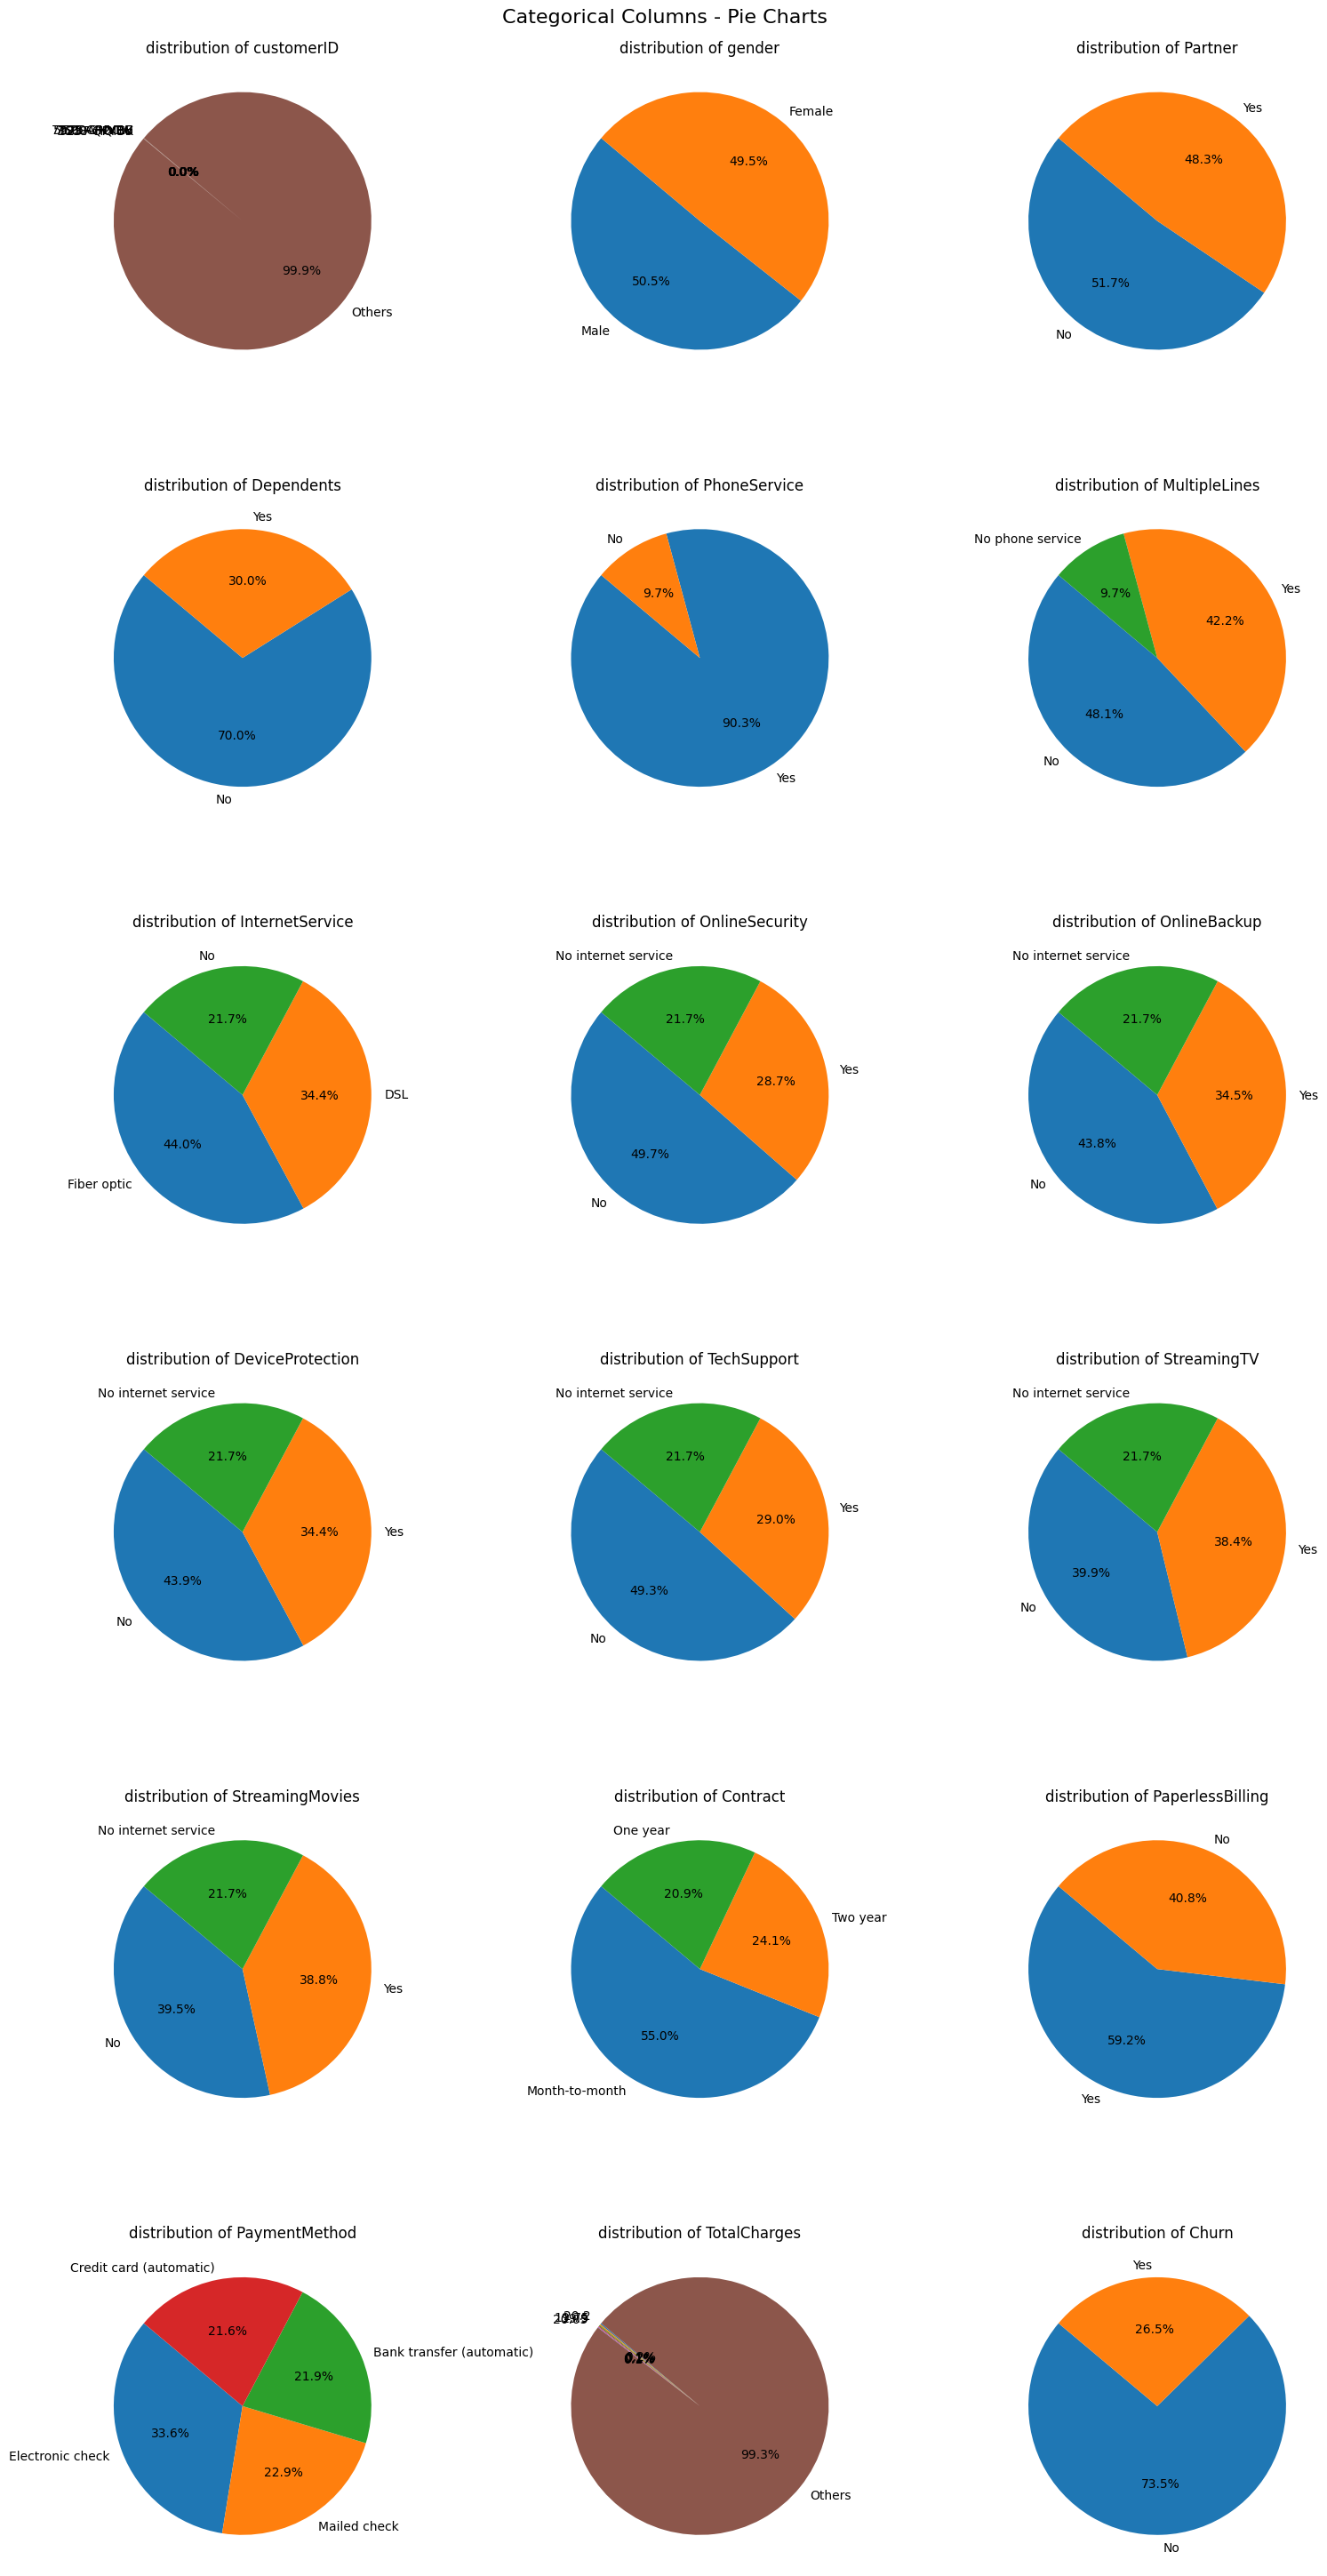

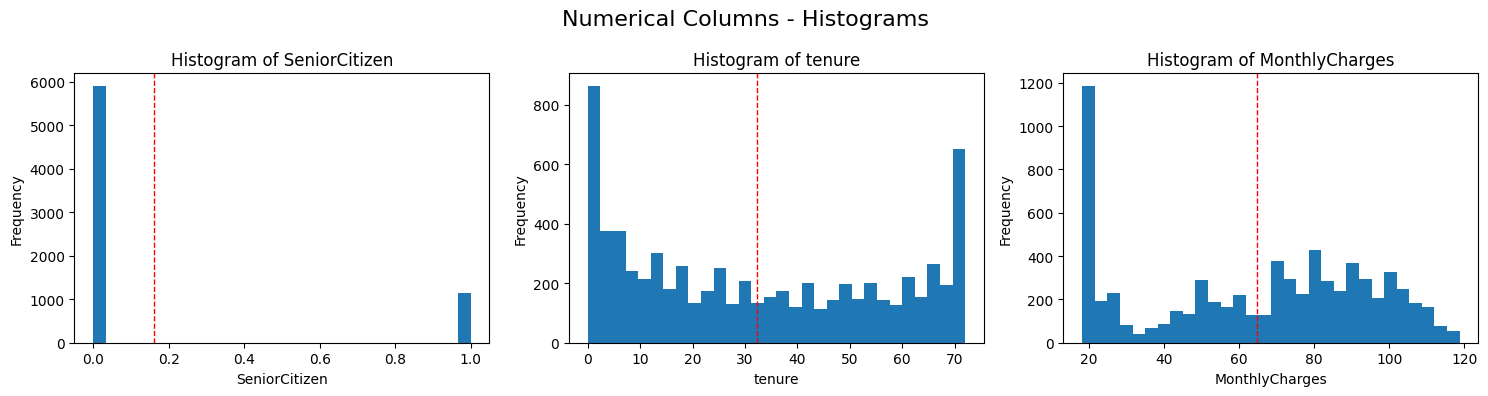

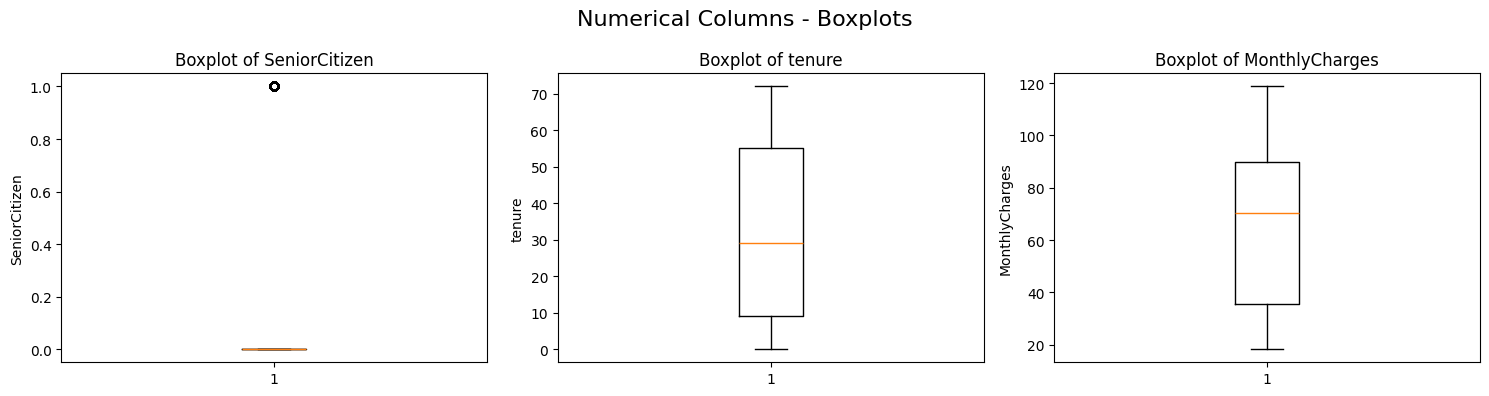

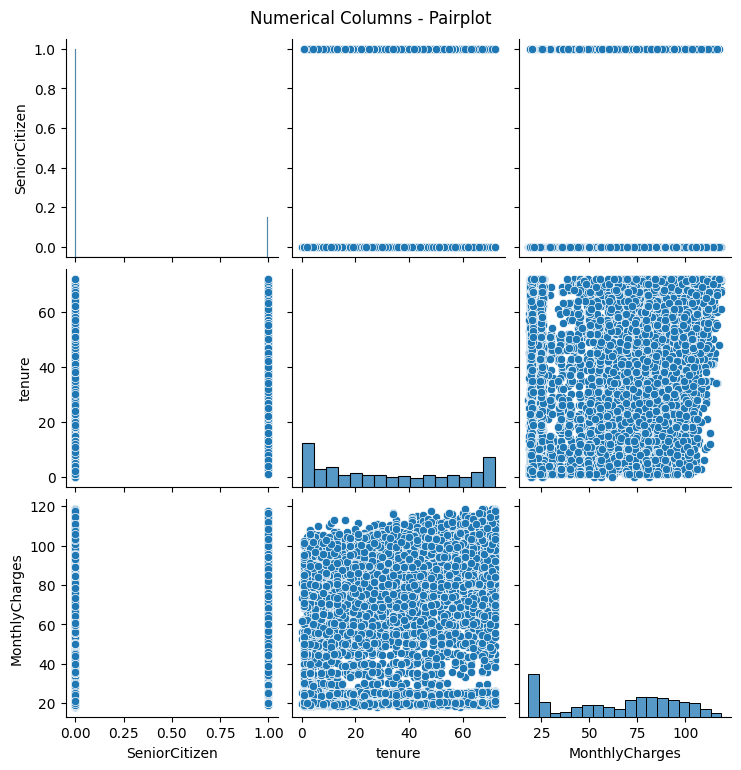

<Figure size 4000x3000 with 0 Axes>

In [7]:
def eda_plots(df):
    categorical_cols = df.select_dtypes(include=["object", "category"]).columns
    numerical_cols = df.select_dtypes(include="number").columns

    # -----------------------------
    # Pie Charts (Categorical)
    # -----------------------------
    if len(categorical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(categorical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 5 * n_rows))
        for i, col in enumerate(categorical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            values = df[col].value_counts()
            top = values.head(5)
            if len(values) > 5:
                others = values[5:].sum()
                top["Others"] = others
            plt.pie(top, labels=top.index, autopct="%1.1f%%", startangle=140)
            plt.ylabel("")
            plt.title(f"distribution of {col}")

        plt.suptitle("Categorical Columns - Pie Charts", fontsize=16)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Histograms (Numerical)
    # -----------------------------
    if len(numerical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))
        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            mean = df[col].mean()
            plt.axvline(mean, color="r", linestyle="dashed", linewidth=1)
            plt.hist(df[col].dropna(), bins=30)
            plt.title(f"Histogram of {col}")
            plt.xlabel(col)
            plt.ylabel("Frequency")

        plt.suptitle("Numerical Columns - Histograms", fontsize=16)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Boxplots (Numerical)
    # -----------------------------
    if len(numerical_cols) > 0:
        n_cols = 3
        n_rows = math.ceil(len(numerical_cols) / n_cols)

        plt.figure(figsize=(5 * n_cols, 4 * n_rows))
        for i, col in enumerate(numerical_cols, 1):
            plt.subplot(n_rows, n_cols, i)
            plt.boxplot(df[col].dropna())
            plt.title(f"Boxplot of {col}")
            plt.ylabel(col)

        plt.suptitle("Numerical Columns - Boxplots", fontsize=16)
        plt.tight_layout()
        plt.show()

    # -----------------------------
    # Pairplots (Numerical)
    # -----------------------------
    if len(numerical_cols) > 1:
        pair = sns.pairplot(df[numerical_cols].dropna())
        pair.figure.suptitle("Numerical Columns - Pairplot", y=1.02)
        plt.figure(figsize=(40, 30))
        plt.show()


eda_plots(df_og)

#### Conclusion:
- **Pie chart:**
  - CustomerID is a useless column that contains the Unique ID Number of each customer and won't be of much help for prediction at all so we will just drop it.
  - Gender and Partner feature is very balanced.
  - 70% peoples aren't Dependants.
  - only 9.7% of people don't use phones.
  - 48.3% of people don't have multiple lines and also even in that 9.7% has label of "no phone service" which is same as having "no phone" which we saw the above feature which also indicates a very strong and truthful source of data.
  - 44% of people use Fiber Optic making it the most popular internet source.
  - Nearly 50% of people don't have Online Security.
  - 44% of people don't have any Online Backup.
  - Nearly 50% of people don't have Tech Support.
  - Subscription of streaming service and TV Services is very well distributed between those who have internet plans, 40$ of people have and 40% of people don't have those subscriptions.
  - Over 50% of people are on Month-to-Month plan.
  - Nearly 60% of people do Paperless Billing.
  - Most people just prefer to pay with Electric Check.
  - TotalCharges is a numerical column which is incorrectly identified as categorical, but we don't need to change it, we will just drop it because upon further investigation, we can find that TotalCharges is just tenure multiplied by MonthlyCharges.
- **Histogram:**
  - Our data isn't normally distributed so we will have to scale it.
- **Boxplot:**
  - SeniorCitizen have some outliers but in this dataset outliers are useful because senior citizens might churn.
- **Pairplot:**
  - No column has strong correlation with each other.

### Target Variable Analysis - Churn

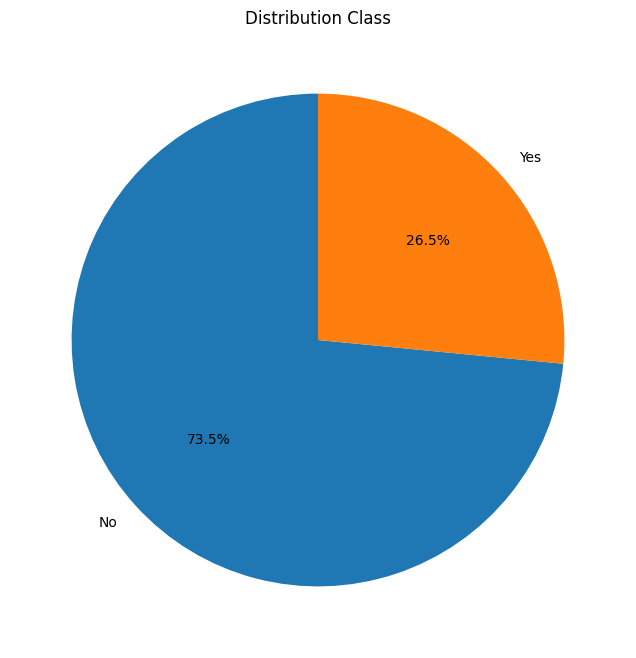

In [8]:
target_feature = 'Churn'

values = df_og[target_feature].value_counts()
plt.figure(figsize=(8, 8))
plt.title("Distribution Class")
plt.pie(values, autopct="%1.1f%%", startangle=90, labels=values.index)
plt.show()

Our target feature isn't well distributed so we will use `stratify = y` during training and testing split.

## Feature Selection

### Make a copy of the Data

In [9]:
df = df_og.copy(deep=True)

Convert TotalCharges to numerical

In [10]:
# Convert to numeric, turning errors (like " ") into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for NaNs (usually where tenure is 0)
print(f"Missing values after conversion: {df['TotalCharges'].isnull().sum()}")

# Fill with 0 or drop them (since they are new customers)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

Missing values after conversion: 11


### VIF for numerical column

In [11]:
num_cols = df.select_dtypes(include='number').columns
X_num = df[num_cols]

vif_data = pd.DataFrame()
vif_data["Feature"] = X_num.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_num.values, i) for i in range(len(X_num.columns))
]
print(vif_data)

          Feature       VIF
0   SeniorCitizen  1.257276
1          tenure  6.332627
2  MonthlyCharges  3.694794
3    TotalCharges  8.080935


TotalCharges has quite High VIF, so we will drop it

### Chi-Square test for categorical column

In [12]:
X_cat = df.select_dtypes(include=["object"]).drop(
    columns=["CustomerID", "Churn"], errors="ignore"
)
le = LabelEncoder()

X_cat_encoded = X_cat.apply(le.fit_transform)
y_encoded = le.fit_transform(df["Churn"])

# Calculate Chi-Square scores
chi_scores = chi2(X_cat_encoded, y_encoded)

# Save it in a dataframe
chi_results = pd.DataFrame(
    {"Feature": X_cat.columns, "Chi2 Score": chi_scores[0], "P-Value": chi_scores[1]}
)

# Sort by P-Value (Lowest P-Value = Most Important)
chi_results = chi_results.sort_values(by="P-Value", ascending=True)

# Format the float output to 6 decimal places
pd.options.display.float_format = "{:.6f}".format

# A logic column to see what to drop immediately
chi_results["Significant?"] = chi_results["P-Value"] < 0.05

print(chi_results)

             Feature  Chi2 Score  P-Value  Significant?
0         customerID 2516.968803 0.000000          True
13          Contract 1115.780167 0.000000          True
7     OnlineSecurity  551.611529 0.000000          True
10       TechSupport  523.303866 0.000000          True
8       OnlineBackup  230.086520 0.000000          True
9   DeviceProtection  191.303140 0.000000          True
3         Dependents  133.036443 0.000000          True
14  PaperlessBilling  105.680863 0.000000          True
2            Partner   82.412083 0.000000          True
15     PaymentMethod   58.492250 0.000000          True
6    InternetService    9.821028 0.001725          True
5      MultipleLines    9.746921 0.001796          True
12   StreamingMovies    8.235399 0.004108          True
11       StreamingTV    7.490203 0.006204          True
1             gender    0.258699 0.611016         False
4       PhoneService    0.097261 0.755142         False


From here we will drop: gender, PhoneService, customerID

### Drop the useless columns

In [13]:
cols_to_drop = ["customerID", "gender", "PhoneService", "TotalCharges"]

df = df.drop(columns=cols_to_drop)

print(df.shape)

df.head()

(7043, 17)


,SeniorCitizen,Partner,Dependents,tenure,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn
0,0,Yes,No,1,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850000,No
1,0,No,No,34,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950000,No
2,0,No,No,2,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850000,Yes
3,0,No,No,45,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300000,No
4,0,No,No,2,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700000,Yes


## Target Feature and Input split

In [14]:
X = df.drop(target_feature, axis=1)
y = df[target_feature]

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")

X Shape: (7043, 16)
y Shape: (7043,)


In [15]:
LE = LabelEncoder()
y = LE.fit_transform(y)

## Train Test Split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.2
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (5634, 16)
X_test shape: (1409, 16)
y_train shape: (5634,)
y_test shape: (1409,)


## Defining Preprocessors

In [17]:
# 1. Define feature groups
num_cols= X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(include="object").columns

# ---------------------------------------------------------
# PIPELINE 1: For Linear/Distance Models (LogReg, SVM, KNN)
# Strategy: StandardScaler + OneHotEncoder
# ---------------------------------------------------------
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ],
    remainder="passthrough",
)

# ---------------------------------------------------------
# PIPELINE 2: For Tree-Based Models (RF, XGB, LGBM, DT)
# Strategy: No Scaling (Passthrough) + OrdinalEncoder
# ---------------------------------------------------------
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        (
            "cat",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
            cat_cols,
        ),
    ],
    remainder="passthrough",
)

# ---------------------------------------------------------
# PIPELINE 3: For Neural Networks
# Strategy: MinMaxScaler + OneHotEncoder
# ---------------------------------------------------------
nn_preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), num_cols),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            cat_cols,
        ),
    ],
    remainder="passthrough",
)

## Model Pipeline

In [18]:
models = {
    # Linear / Distance Group
    "Logistic Regression": Pipeline(
        [("pre", linear_preprocessor), ("clf", LogisticRegression(max_iter=1000))]
    ),
    "SVC": Pipeline([("pre", linear_preprocessor), ("clf", SVC(probability=True))]),
    "KNN": Pipeline([("pre", linear_preprocessor), ("clf", KNeighborsClassifier())]),
    # Tree-Based Group
    "Decision Tree": Pipeline(
        [("pre", tree_preprocessor), ("clf", DecisionTreeClassifier())]
    ),
    "Random Forest": Pipeline(
        [("pre", tree_preprocessor), ("clf", RandomForestClassifier())]
    ),
    "XGBoost": Pipeline(
        [("pre", tree_preprocessor), ("clf", XGBClassifier(eval_metric="logloss"))]
    ),
    "LightGBM": Pipeline(
        [("pre", tree_preprocessor), ("clf", LGBMClassifier(verbose=-1))]
    ),
}

## Model Training

In [19]:
results_list = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    recall = recall_score(y_test, y_pred)
    
    results_list.append({"Model": name, "Recall": recall})

    print(f"Training done for {name}")

ML_Results = pd.DataFrame(results_list).sort_values(by="Recall", ascending=False)

ML_Results

Training done for Logistic Regression
Training done for SVC
Training done for KNN
Training done for Decision Tree
Training done for Random Forest
Training done for XGBoost
Training done for LightGBM


,Model,Recall
0,Logistic Regression,0.548128
5,XGBoost,0.532086
3,Decision Tree,0.518717
6,LightGBM,0.513369
2,KNN,0.508021
4,Random Forest,0.494652
1,SVC,0.481283


As we can see, no model can beat our base model here which is Logistic Regression, so if this was a pure ML project then we would have made Logistic Regression as the best model for this project and then would've done Hyperparameter tuning on this.

## Hyperparamter tuning for Logistic Regression

In [20]:
# Define the pipeline
lr_pipeline = Pipeline([("pre", linear_preprocessor), ("clf", LogisticRegression())])

# Define the Hyperparameter Grid
param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],  # From strong to weak regularization
    "clf__penalty": ["l1", "l2"],  # Lasso vs Ridge
    "clf__solver": ["liblinear", "saga"],  # Solvers that support L1/L2
    "clf__max_iter": [2000],  # Ensure it converges
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,  # 5-Fold Cross Validation
    scoring="recall",  # Optimizing specifically for Recall
    n_jobs=-1,  # Use all CPU cores
    verbose=1,
    refit=True,
)

# Train
print("Tuning Logistic Regression for best Recall...")
grid_search.fit(X_train, y_train)

# Results
best_lr = grid_search.best_estimator_
print(f"\nBest Recall Score (CV): {grid_search.best_score_:.4f}")
print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate on Test Set
test_recall = recall_score(y_test, best_lr.predict(X_test))
print(f"Test Set Recall: {test_recall:.4f}")

Tuning Logistic Regression for best Recall...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best Recall Score (CV): 0.5452
Best Parameters: {'clf__C': 100, 'clf__max_iter': 2000, 'clf__penalty': 'l1', 'clf__solver': 'saga'}
Test Set Recall: 0.5428


The best score we can get on Logistic Regression is here, so we will compare this to ANN

## Artificial Neural Network

In [21]:
X_train_nn = nn_preprocessor.fit_transform(X_train)
X_test_nn = nn_preprocessor.transform(X_test)

input_shape = X_train_nn.shape[1]

In [22]:
# ---------------------------------------------------------
# 1. SETUP: Data & Grid
# ---------------------------------------------------------
y_train_arr = np.array(y_train)
input_shape = X_train_nn.shape[1]

optimizers_list = ["Adam", "RMSprop", "SGD"]
learning_rates = [0.01, 0.001, 0.0001]
batch_sizes = [32, 64]

kfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


# ---------------------------------------------------------
# 2. HELPER: Model Builder
# ---------------------------------------------------------
def build_model(input_shape, optimizer_name, lr):
    keras.backend.clear_session()
    model = Sequential(
        [
            Dense(64, activation="relu", input_shape=(input_shape,)),
            Dropout(0.3),
            Dense(32, activation="relu"),
            Dropout(0.3),
            Dense(1, activation="sigmoid"),
        ]
    )

    if optimizer_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    elif optimizer_name == "RMSprop":
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.SGD(learning_rate=lr)

    model.compile(
        loss="binary_crossentropy",
        optimizer=opt,
        metrics=[keras.metrics.Recall(name="recall")],
    )
    return model


# ---------------------------------------------------------
# 3. EXECUTE: The CV Loop with RLR
# ---------------------------------------------------------
cv_results_list = []

print(f"Starting 3-Fold CV Search with RLR + ES...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:

            fold_recalls = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            for fold_idx, (train_idx, val_idx) in enumerate(
                kfold.split(X_train_nn, y_train_arr)
            ):

                # A. Data Prep
                X_fold_train, X_fold_val = X_train_nn[train_idx], X_train_nn[val_idx]
                y_fold_train, y_fold_val = y_train_arr[train_idx], y_train_arr[val_idx]

                # B. Class Weights
                cw = class_weight.compute_class_weight(
                    "balanced", classes=np.unique(y_fold_train), y=y_fold_train
                )
                cw_dict = {0: cw[0], 1: cw[1]}

                # C. Build
                model = build_model(input_shape, opt_name, lr)

                # D. Callbacks (RLR + ES)
                es = EarlyStopping(
                    monitor="val_loss", patience=12, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=6, min_lr=1e-6
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=60,  # Slightly more epochs to allow RLR to trigger
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    class_weight=cw_dict,
                    verbose=0,
                )

                # E. Evaluate
                y_pred = (model.predict(X_fold_val, verbose=0) > 0.5).astype(int)
                fold_recalls.append(recall_score(y_fold_val, y_pred))

            mean_recall = np.mean(fold_recalls)
            std_recall = np.std(fold_recalls)

            print(
                f"Config: {config_name:25} | Mean Recall: {mean_recall:.4f} | Std: {std_recall:.4f}"
            )

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean Recall": mean_recall,
                    "Std": std_recall,
                }
            )

# ---------------------------------------------------------
# 4. RESULTS
# ---------------------------------------------------------
CV_Results = pd.DataFrame(cv_results_list).sort_values(
    by="Mean Recall", ascending=False
)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS (WITH RLR)")
print("=" * 40)
print(CV_Results.head(5))

Starting 3-Fold CV Search with RLR + ES...
-----------------------------------------------------------------
Config: Adam_LR0.01_BS32          | Mean Recall: 0.7311 | Std: 0.0302
Config: Adam_LR0.01_BS64          | Mean Recall: 0.7224 | Std: 0.0349
Config: Adam_LR0.001_BS32         | Mean Recall: 0.7592 | Std: 0.0045
Config: Adam_LR0.001_BS64         | Mean Recall: 0.7625 | Std: 0.0058
Config: Adam_LR0.0001_BS32        | Mean Recall: 0.7739 | Std: 0.0176
Config: Adam_LR0.0001_BS64        | Mean Recall: 0.7913 | Std: 0.0061
Config: RMSprop_LR0.01_BS32       | Mean Recall: 0.7251 | Std: 0.0372
Config: RMSprop_LR0.01_BS64       | Mean Recall: 0.7191 | Std: 0.0196
Config: RMSprop_LR0.001_BS32      | Mean Recall: 0.7505 | Std: 0.0098
Config: RMSprop_LR0.001_BS64      | Mean Recall: 0.7732 | Std: 0.0058
Config: RMSprop_LR0.0001_BS32     | Mean Recall: 0.7732 | Std: 0.0061
Config: RMSprop_LR0.0001_BS64     | Mean Recall: 0.7900 | Std: 0.0123
Config: SGD_LR0.01_BS32           | Mean Recall: 0.

Our best ANN's configuration is
- Optimiser: RMSprop
- Learning Rate: 0.0001
- Batch Size: 64

Resulting Recall: 0.78

So we can just train and save this exact neural network for future usage

Training Final Production Model...
Epoch 1/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4431 - loss: 0.7068 - recall: 0.6500 - val_accuracy: 0.6114 - val_loss: 0.6748 - val_recall: 0.6237 - learning_rate: 1.0000e-04
Epoch 2/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5609 - loss: 0.6717 - recall: 0.6275 - val_accuracy: 0.7116 - val_loss: 0.6320 - val_recall: 0.6407 - learning_rate: 1.0000e-04
Epoch 3/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6228 - loss: 0.6506 - recall: 0.6225 - val_accuracy: 0.7329 - val_loss: 0.6026 - val_recall: 0.6780 - learning_rate: 1.0000e-04
Epoch 4/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6694 - loss: 0.6284 - recall: 0.6367 - val_accuracy: 0.7267 - val_loss: 0.5829 - val_recall: 0.7017 - learning_rate: 1.0000e-04
Epoch 5/150
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6956 - loss: 0.6042 - recall: 0.6617 - val_accuracy: 0.7294 - val_loss: 0.5621 - val_recall: 0.7119 - learning_rate: 1.0000e-04


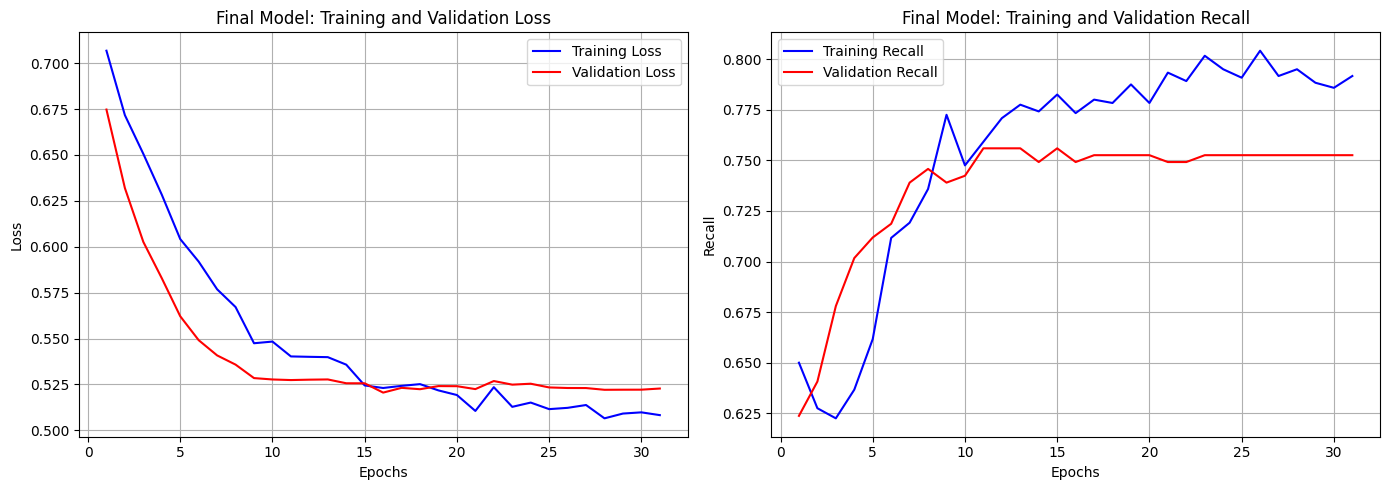

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

--- Final Production Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.50      0.76      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.74      0.75      1409



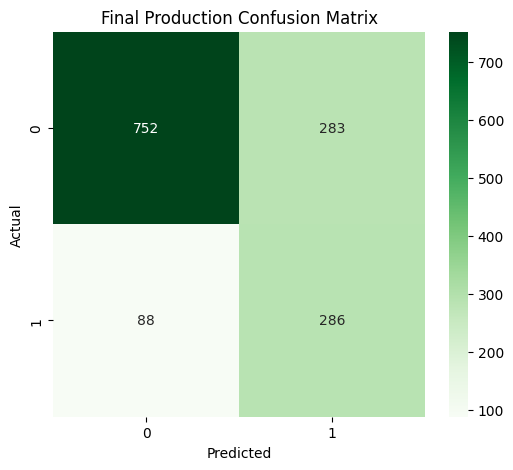

Production model saved as 'churn_model.keras'


In [23]:
# 1. Clear session for a clean final run
keras.backend.clear_session()

# 2. Build the Champion Architecture
final_model = Sequential(
    [
        Dense(64, activation="relu", input_shape=(X_train_nn.shape[1],)),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.3),
        Dense(1, activation="sigmoid"),
    ]
)

# 3. Compile with the CV Winner (Adam 0.0001)
final_model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.Adam(learning_rate=0.0001),
    metrics=["accuracy", keras.metrics.Recall(name="recall")],
)

# 4. Final Callbacks
# Using a slightly higher patience to allow the 0.0001 LR to converge fully
final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=15, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

# 5. Execute Final Training
print("Training Final Production Model...")
final_history = final_model.fit(
    X_train_nn,
    y_train_arr,
    validation_split=0.2,
    epochs=150,
    batch_size=64,
    class_weight=cw_dict,
    callbacks=final_callbacks,
    verbose=1,
)


# ---------------------------------------------------------
# 6. EVALUATION: History Curves
# ---------------------------------------------------------
def plot_final_performance(history):
    acc = history.history["recall"]
    val_acc = history.history["val_recall"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(14, 5))

    # Loss Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, "b", label="Training Loss")
    plt.plot(epochs, val_loss, "r", label="Validation Loss")
    plt.title("Final Model: Training and Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Recall Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, "b", label="Training Recall")
    plt.plot(epochs, val_acc, "r", label="Validation Recall")
    plt.title("Final Model: Training and Validation Recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_final_performance(final_history)

# ---------------------------------------------------------
# 7. EVALUATION: Metrics & Confusion Matrix
# ---------------------------------------------------------
y_pred_probs = final_model.predict(X_test_nn)
y_pred = (y_pred_probs > 0.5).astype(int)

print("\n--- Final Production Classification Report ---")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Greens")
plt.title("Final Production Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 8. Final Save
final_model.save("churn_model.keras")
print("Production model saved as 'churn_model.keras'")

## Conclusion

- Our very best ML Model was `Logistic regression` with Recall of 54%, meaning we are catching 5 out 10 people who will churn.
- Our best ANN had the recall of 76%, meaning we will catch nearly 8 out of 10 people who will churn.